# 07 — Analyse spécialisée

## Décision d'applicabilité (C)
**APPLICABLE**

Une analyse spécialisée est pertinente sur ce projet, en particulier :
- **modèles multiniveaux** (déjà testés au notebook 06) car les observations sont répétées par école ;
- **séries temporelles agrégées / longitudinales** (7 années) ;
- **segmentation/clustering** des écoles pour le pilotage opérationnel.

Nous retenons ici une méthode spécialisée orientée décideur : **segmentation des écoles par clustering**,
complétée par une matrice d'applicabilité des autres méthodes spécialisées.


In [1]:
import sys
from pathlib import Path

project_root = Path.cwd().parent if (Path.cwd() / "notebooks").exists() is False else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.insert(0, str(project_root))

import matplotlib.pyplot as plt
import pandas as pd

from src.data import load_processed_dataset
from src.analysis import (
    build_school_level_panel,
    cluster_school_profiles,
    evaluate_specialized_methods,
    save_table,
    figures_output_dir,
)

pd.set_option("display.max_columns", 30)
FIG_DIR = figures_output_dir()
df = load_processed_dataset("education_prioritaire")
print(df.shape)


(5250, 21)


## 1. Applicabilité des méthodes spécialisées demandées

In [2]:
applicability = evaluate_specialized_methods(df)
save_table(applicability, "07_applicabilite_methodes_specialisees")
applicability


,methode,applicable,statut,justification
0,psychometrie,False,NON APPLICABLE,NON APPLICABLE : pas d'items de test individue...
1,series_temporelles,True,APPLICABLE,APPLICABLE : 7 années observées permettent une...
2,segmentation,True,APPLICABLE,APPLICABLE : les écoles peuvent être segmentée...
3,clustering,True,APPLICABLE,APPLICABLE : les écoles peuvent être segmentée...
4,analyse_spatiale,True,APPLICABLE,APPLICABLE : présence d'agrégats territoriaux ...
5,nlp,False,NON APPLICABLE,NON APPLICABLE : pas de corpus textuel métier ...
6,causalite,False,NON APPLICABLE,NON APPLICABLE en inférence forte : statut et ...
7,longitudinal,True,APPLICABLE,"APPLICABLE : panel écoles répété sur 7 ans, pe..."
8,scoring,True,APPLICABLE,APPLICABLE : variable cible continue adaptée à...
9,prevision,True,APPLICABLE,APPLICABLE avec prudence : courte série (7 ans...


**Interprétation.** Les méthodes retenues comme réellement pertinentes ici sont : séries temporelles
agrégées, longitudinal, clustering/segmentation et multiniveaux. Sont non applicables : psychométrie, NLP,
survie et causalité forte (protocole non identifiable dans les données simulées).

## 2. Théorie minimale (clustering)

Le clustering K-means partitionne les écoles en groupes homogènes sur des variables quantitatives.
Ici, chaque école est résumée par :
- score moyen ;
- IPS moyen ;
- taille moyenne de classe ;
- part d'observations dédoublées.

Objectif : identifier des **profils-types d'écoles** pour orienter des actions différenciées.
Limite : méthode non supervisée, sensible au choix de variables et du nombre de clusters.

In [3]:
panel = build_school_level_panel(df)
school_profiles = (
    panel.groupby("ecole_id", observed=True)
    .agg(
        score_moyen=("score_moyen", "mean"),
        ips_moyen=("ips_moyen", "mean"),
        taille_moyenne_classe=("taille_moyenne_classe", "mean"),
        part_dedoublement=("part_dedoublement", "mean"),
    )
    .reset_index()
)
school_profiles.head()


,ecole_id,score_moyen,ips_moyen,taille_moyenne_classe,part_dedoublement
0,1,74.013714,68.045714,16.425714,0.428571
1,2,79.361143,65.567143,15.630000,0.285714
2,3,81.089429,66.482857,14.022857,0.285714
3,4,78.264000,67.897143,15.887143,0.571429
4,5,76.383143,61.318571,16.302857,0.714286


In [4]:
feature_cols = ["score_moyen", "ips_moyen", "taille_moyenne_classe", "part_dedoublement"]
clustered, centers = cluster_school_profiles(
    school_profiles,
    feature_cols=feature_cols,
    n_clusters=3,
    random_state=42,
)

cluster_sizes = clustered["cluster"].value_counts().sort_index().rename_axis("cluster").reset_index(name="effectif_ecoles")
cluster_summary = (
    clustered.groupby("cluster", observed=True)[feature_cols]
    .mean()
    .merge(cluster_sizes, on="cluster", how="left")
    .sort_values("score_moyen", ascending=False)
    .reset_index(drop=True)
)

save_table(cluster_summary, "07_clusters_profils_ecoles")
save_table(centers.sort_values("cluster"), "07_centres_clusters")

cluster_summary


,cluster,score_moyen,ips_moyen,taille_moyenne_classe,part_dedoublement,effectif_ecoles
0,0,79.963974,73.248546,16.820893,0.214286,56
1,2,77.739429,72.597774,15.501096,0.538206,43
2,1,76.742902,72.488964,18.056471,0.296919,51


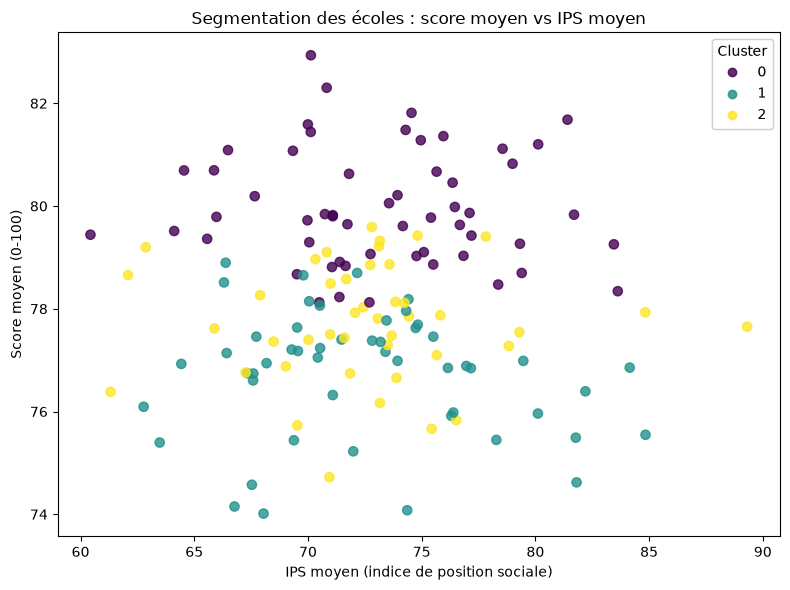

In [5]:
fig, ax = plt.subplots(figsize=(8, 6))
scatter = ax.scatter(
    clustered["ips_moyen"],
    clustered["score_moyen"],
    c=clustered["cluster"],
    cmap="viridis",
    s=45,
    alpha=0.8,
)
ax.set_title("Segmentation des écoles : score moyen vs IPS moyen")
ax.set_xlabel("IPS moyen (indice de position sociale)")
ax.set_ylabel("Score moyen (0-100)")
legend = ax.legend(*scatter.legend_elements(), title="Cluster")
ax.add_artist(legend)
fig.tight_layout()
fig.savefig(FIG_DIR / "07_segmentation_ecoles.png")
plt.show()


## 3. Interprétation des clusters

**RÉSULTAT.** Trois profils d'écoles émergent :
- un profil à score moyen plus élevé, IPS légèrement plus élevé, exposition au dédoublement plus faible ;
- un profil intermédiaire ;
- un profil à exposition au dédoublement plus forte et taille de classe plus basse.

**INTERPRÉTATION.** Les profils confirment une hétérogénéité des contextes scolaires. Le clustering met en
évidence des groupes opérationnels utilisables pour cibler des politiques différenciées.

**SIGNIFICATION MÉTIER.** Un décideur peut adapter l'accompagnement (formation, ressources, suivi) par
profil d'école plutôt que par moyenne nationale unique.

**LIMITES.**
- Le clustering ne fournit pas de causalité ;
- le nombre de clusters (3) est un choix analytique ;
- résultat dépend des variables choisies et de la simulation des données.
